In [1]:
%cd ..
%load_ext autoreload
%autoreload 2

/home/dongmin/userdata/open-score-string-quartets


/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import os
import sys
import subprocess
import warnings
from typing import Union, Any, Optional
import shutil
from pathlib import Path
import difflib
from collections import Counter, defaultdict
from operator import itemgetter, contains, eq # contains(A, B) == (B in A), eq(A, B) == (A == B)
from itertools import groupby
from tempfile import NamedTemporaryFile, TemporaryDirectory

import math
import random

import json
import csv
import strictyaml as syaml

from tqdm import tqdm
import matplotlib.pyplot as plt

import cv2
import numpy as np
import music21

import kernpy as kp

import xml.etree.ElementTree as ET
from modules.lmxe.lmxe import linearize_lmxe, delinearize_lmxe
from modules.lmxe.lmxe import split_tokens_by_key_token
from modules.lmxe.lmxe.Linearizer import SQLinearizer
from modules.lmxe.lmxe.Delinearizer import SQDelinearizer
from modules.lmxe.lmxe.LMXEFile import LMXEFile, LMXEMetadata, get_score_type
from modules.lmxe.lmxe.symbolic.MxlFile import MusicXMLFile
from modules.lmxe.lmxe.symbolic.part_to_score import parts_to_score
from modules.lmxe.lmxe.symbolic.debug_compare import compare_parts

from scripts.mscx_utils import render_lmx
from scripts.utils import get_ts, PathLike, dformat, dprint
from scripts.utils import crop_white_space, load_ossq_metadata

from IPython.core.magic import register_cell_magic
@register_cell_magic
def skip(line, cell):
  return

/home/dongmin/.local/share/virtualenvs/open-score-string-quartets-wd2Cnojv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load metadata

In [3]:
ossq_metadata = load_ossq_metadata(Path.cwd() / 'data' / 'scores_w_infos.yaml')
len(ossq_metadata)

122

In [4]:
sq_dataset_dir = Path.home() / 'userdata' / 'open-score-string-quartets' / 'scores'
sq_dataset_dir.exists()

True

## KERN => BEKERN

In [6]:
score_dirs = [
  Path.cwd() / 'scores' / v['path']
  for k, v in ossq_metadata.items()
]

len(score_dirs), all([p.exists() for p in score_dirs])

(122, True)

In [46]:
random.seed(42)
random.seed(950609)
random.seed(940407)
sample_dir = random.choice(score_dirs)
print(f"Sample Directory: {sample_dir}")

kern_paths = (sample_dir / 'lmxe').glob('*.krn')
kern_paths = sorted(kern_paths)

sample_kern = random.choice(kern_paths)

len(kern_paths), sample_kern

Sample Directory: /home/dongmin/userdata/open-score-string-quartets/scores/Brahms,_Johannes/String_Quartet_No.1,_Op.51_No.1


(117,
 PosixPath('/home/dongmin/userdata/open-score-string-quartets/scores/Brahms,_Johannes/String_Quartet_No.1,_Op.51_No.1/lmxe/sq7108150:0019:0004.krn'))

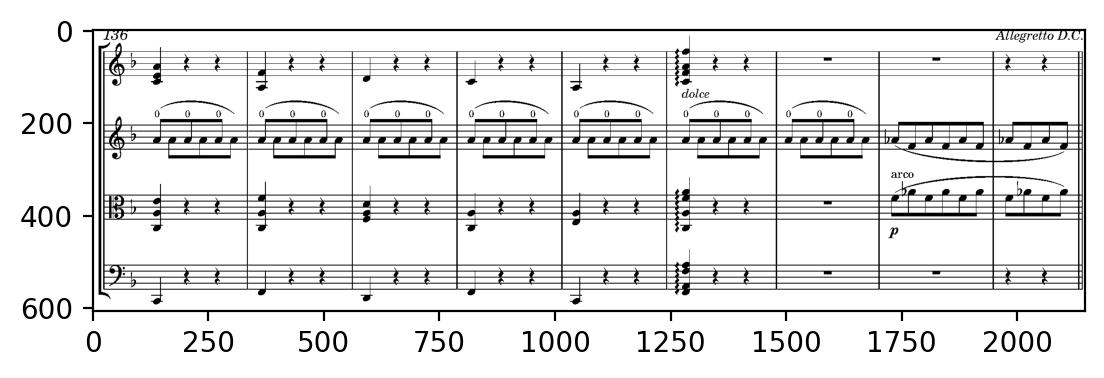

In [47]:
sample_img = cv2.imread((sample_kern.parent.parent / 'images' / 'synthetic' / 'cropped' / f'{sample_kern.stem}.png'), cv2.IMREAD_UNCHANGED)
plt.plot(dpi=300)
plt.imshow(sample_img, cmap='gray')

In [48]:
document, err = kp.load(sample_kern)

In [52]:
document.get_spine_ids()

[0, 1, 2, 3]

In [56]:
print(
  kp.dumps(
    document,
    # './temp.bekrn',
    encoding=kp.Encoding.eKern,
    spine_ids=[0]
  )
)

**ekern
*part4
*staff4
*I"Part 4
*clefF4
*k[b-]
=
4@CC·/
4@r
4@r
=
4@FF·/
4@r
4@r
=
4@DD·/
4@r
4@r
=
4@FF·/
4@r
4@r
=
4@CC·/
4@r
4@r
=
4@FF·: 4@AA·: 4@F·: 4@A·:
4@r
4@r
=
1@r
=
1@r
=
4@r
4@r
=
*-



In [42]:
document, _ = kp.load('./temp.bekrn')

## MusicXML => KERN => MusicXML Verification

In [21]:
log_file_path = './krn_errors_2025-10-23-09:50:33.log'
log_file_path = './krn_errors_2025-10-23-11:51:55.log'

In [22]:
%pdb off

with open(log_file_path, 'r') as f:
  log = f.read()

log = log.split('\n\n')
log = [l.split('\n') for l in log if l.strip()]

failed_segments = []
prob_parts_dict = defaultdict( lambda: defaultdict(list) )

total_cnt = 0

for score in log:
  segment_id, *results = score
  segment_id = segment_id.split()[1]

  # skip excluded pieces
  if segment_id.split(':')[0] in {'sq7358708', 'sq7267316', 'sq7471661' }:
    continue

  total_cnt += 1

  if len(results) == 1 and results[0] == '[ER]: Re-conversion failed':
    failed_segments.append(segment_id)
    continue

  for part in results:
    if '[ER]' in part:
      sig, part_id, *detail = part.split(': ')
      part_id = int(part_id.replace('P', ''))

      if detail[0] == 'Note count differs':
        ref_count, _, reconv_count = detail[1].split()
        prob_parts_dict[segment_id]['count'].append((part_id, int(ref_count), int(reconv_count)))
      else:
          ref_value = detail[1].split()[-3]
          reconv_value = detail[1].split()[-1]

          if 'offset' in detail[1]:
            prob_parts_dict[segment_id]['offset'].append((part_id, float(ref_value), float(reconv_value)))
          elif 'duration' in detail[1]:
            prob_parts_dict[segment_id]['duration'].append((part_id, float(ref_value), float(reconv_value)))
          elif 'value' in detail[1]:
            prob_parts_dict[segment_id]['pitch'].append((part_id, int(ref_value), int(reconv_value)))

Counter(list(
  k
  for v in prob_parts_dict.values()
  for k in v.keys()
))

Automatic pdb calling has been turned OFF


Counter({'count': 3612, 'duration': 3})

In [23]:
total_cnt

13273

In [24]:
len(failed_segments)

87

In [16]:
len(prob_parts_dict)

3681

In [9]:
ef = open('krn_reconv_debug_unified.txt', 'w')

for segment_id, errors in prob_parts_dict.items():
  print(f'-------------- {segment_id} --------------', file=ef)
  for etype, errors in errors.items():
    for part_idx, ref_value, reconv_value in errors:
      xml_dir = sq_dataset_dir / ossq_metadata[segment_id.split(':')[0].replace('sq', '')]['path'] / 'musicxml'
      ref_xml = xml_dir / f'{segment_id}_P{part_idx}.musicxml'
      ref_xml = MusicXMLFile.load_musicxml(ref_xml)
      ref_part = ref_xml.tree.getroot().find('.//part')
      ref_measures = ref_part.findall('measure')

      reconv_xml = xml_dir / f'{segment_id}_P{part_idx}.reconv.musicxml'
      reconv_xml = MusicXMLFile.load_musicxml(reconv_xml)
      reconv_part = reconv_xml.tree.getroot().find('.//part')
      reconv_measures = reconv_part.findall('measure')
      
      print(f'Part {part_idx}: [{etype}]: ref={ref_value}, reconv={reconv_value}', file=ef)
      part_have_error = False

      for m_idx, (ref_measure, reconv_measure) in enumerate(zip(ref_measures, reconv_measures)):
        for ref_el, reconv_el in zip(ref_measure, reconv_measure):
          ET.indent(ref_el)
          e = ET.tostring(ref_el, encoding='unicode')
          ET.indent(reconv_el)
          g = ET.tostring(reconv_el, encoding='unicode')

          diff = difflib.unified_diff(e.splitlines(), g.splitlines(), lineterm='')
          for l in diff:
            print(l, file=ef)
          print(file=ef)

In [10]:
ef.close()

In [17]:
ef = open('./krn_reconv_debug_filtered.txt', 'w')

for segment_id, errors in prob_parts_dict.items():
  print(f'-------------- {segment_id} --------------', file=ef)
  segment_have_error = False
  for etype, errors in errors.items():
    for part_idx, ref_value, reconv_value in errors:
      xml_dir = sq_dataset_dir / ossq_metadata[segment_id.split(':')[0].replace('sq', '')]['path'] / 'musicxml'
      ref_xml = xml_dir / f'{segment_id}_P{part_idx}.musicxml'
      ref_xml = MusicXMLFile.load_musicxml(ref_xml)
      ref_part = ref_xml.tree.getroot().find('.//part')
      ref_measures = ref_part.findall('measure')

      reconv_xml = xml_dir / f'{segment_id}_P{part_idx}.reconv.musicxml'
      reconv_xml = MusicXMLFile.load_musicxml(reconv_xml)
      reconv_part = reconv_xml.tree.getroot().find('.//part')
      reconv_measures = reconv_part.findall('measure')
      
      print(f'Part {part_idx}: [{etype}]: ref={ref_value}, reconv={reconv_value}', file=ef)
      part_have_error = False

      for m_idx, (ref_measure, reconv_measure) in enumerate(zip(ref_measures, reconv_measures)):
        for ref_el, reconv_el in zip(ref_measure, reconv_measure):
          ET.indent(ref_el)
          e = ET.tostring(ref_el, encoding='unicode')
          ET.indent(reconv_el)
          g = ET.tostring(reconv_el, encoding='unicode')

          diff = difflib.SequenceMatcher(
            None,
            e.splitlines(),
            g.splitlines()
          )
          
          pairs = []

          for tag, i1, i2, j1, j2 in diff.get_opcodes():
            if tag == 'delete':
              deleted = e.splitlines()[i1:i2]
              if 'note' in deleted:
                pairs.append(('delete', deleted, []))
                continue

              deleted = [
                l for l in deleted
                if all(k not in l for k in ['duration', 'staff', 'notation', 'stem', 'alter', 'slur', 'tie'])
              ]
              if deleted:
                pairs.append(('delete', deleted, []))

            elif tag == 'insert':
              pairs.append(('insert', [], g.splitlines()[j1:j2]))

            elif tag == 'replace':
              deleted = e.splitlines()[i1:i2]
              inserted = g.splitlines()[j1:j2]

              if 'note' in deleted or '<rest measure="yes">' in deleted:
                pairs.append(('replace', deleted, inserted))
                continue
              
              deleted = [
                l for l in deleted
                if all(k not in l for k in ['duration', 'divisions', 'clef', 'staff', 'notation', 'stem', 'alter', 'slur', 'tie']) and l.strip()
              ]
              inserted = [
                l for l in inserted
                if all(k not in l for k in ['duration', 'divisions', 'clef', 'staff', 'notation', 'stem', 'alter', 'slur', 'tie']) and l.strip()
              ]

              if deleted or inserted:
                pairs.append(('replace', deleted, inserted))

          for tag, deleted, inserted in pairs:
            if tag == 'delete':
              print(f"Deleted: {deleted}", file=ef)
              part_have_error = True
            elif tag == 'insert':
              print(f"Inserted: {inserted}", file=ef)
              part_have_error = True
            elif tag == 'replace':
              print(f"Replaced: {deleted} with {inserted}", file=ef)
              part_have_error = True

      if part_have_error:
        print(file=ef)
    if segment_have_error:
      print(file=ef)


In [18]:
ef.close()

In [25]:
error_segments = [
  'sq7383977:0013:0004',
  'sq7383977:0014:0002',
  'sq7383977:0014:0003',
  'sq7383977:0016:0001',
  'sq7383977:0016:0003',
  'sq7383977:0016:0004',
  'sq7295726:0026:0003',
  'sq8741475:0006:0002',
  'sq8454356:0001:0004',
  'sq8454356:0005:0005',
  'sq8454356:0007:0003',
  'sq8454356:0016:0002',
  'sq8811375:0051:0002',
  'sq8811375:0017:0002',
  'sq8928855:0006:0005',
  'sq8823783:0030:0001',
  'sq8885439:0013:0003',
  'sq9631717:0021:0004',
]

len(error_segments)

18